# HA Attention — Cumulative 80% Mass Analysis (20-Seed × 3-Fold CV)

Analogue of `cell_type_importance_attention_latest.ipynb`'s per-fold cumulative
attention plot, but for the **Hierarchical Attention (HA)** model trained in
`ha_20seeds_3fold_cv.ipynb`.

HA produces **two** attention distributions per donor:
- `w_c`  — softmax over cells *within each cell-type group*  (Level 1)
- `w_ct` — softmax over cell-types *for the donor*           (Level 2)

The combined per-cell contribution to the patient embedding is
`alpha_c = w_ct[ct(c)] * w_c[c]`, and these sum to **1 over all cells of a
donor** — directly comparable to SAP's flat softmax. We analyse three views:

1. **Combined cell weights (alpha_c)** — direct analogue of the SAP 80%-mass plot.
2. **Cell-type weights (w_ct)** — how many cell-types are needed for 80% of
   the Level-2 attention?
3. **Within-celltype cell weights (w_c)** — how concentrated is Level-1
   attention inside a typical cell-type group?

For each seed we evaluate on its **outer-test donors** (10 donors per seed),
matching the train/test split used in Block 10 of the training notebook.


## Setup

Imports, hyperparameters, helpers — these mirror the training notebook so the saved checkpoints load cleanly.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedShuffleSplit
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from torch_geometric.utils import softmax as pyg_softmax
from torch_geometric.nn import global_add_pool, global_mean_pool

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [2]:
# ── Match ha_20seeds_3fold_cv.ipynb exactly ──────────────────────────────
DATA_PATH      = "../data_healthy_inflamed/kong_5000_healthy_inflamed_5000hvg.h5ad"
PATIENT_ID_KEY = "donor_id"
LABEL_KEY      = "Type"
CELL_TYPE_KEY  = "Celltype"
EMBEDDING_KEY  = "X_scGPT"
LABEL_MAP      = {"Heal": 0, "Infl": 1}
LABEL_NAMES    = {0: "Normal", 1: "Inflamed"}
DISEASE_PALETTE = {"Normal": "#1f77b4", "Inflamed": "#d62728"}
NUM_CLASSES    = 2

ATTN1, ATTN2   = True, True
N_HID          = 256
N_LAYERS_LIN   = 1
DROPOUT        = 0.3

SEEDS          = list(range(20))
TEST_SIZE      = 6

CKPT_DIR       = "checkpoints_20seeds"
OUTPUT_DIR     = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

THRESHOLD = 0.80

## HA model — instrumented to return attention weights

Identical parameter layout to the training notebook's `HAModel`, but `forward` also returns `(w_c, w_ct)` so we can inspect them.

In [3]:
class HAModel(nn.Module):
    """Same architecture/weights as the training notebook. forward() additionally
    returns the Level-1 (`w_c`) and Level-2 (`w_ct`) attention tensors."""
    def __init__(self, n_in, n_out=2, attn1=True, attn2=True,
                 dropout=0.0, n_layers_lin=1, n_hid=256):
        super().__init__()
        self.attn1 = attn1
        self.attn2 = attn2

        layers = []
        for i in range(n_layers_lin):
            c_in  = n_in if i == 0 else n_hid
            c_out = n_hid
            layers += [nn.Linear(c_in, c_out), nn.ReLU(), nn.Dropout(dropout)]
        self.lin = nn.Sequential(*layers)
        curr_in  = n_in if len(self.lin) == 0 else n_hid
        self.n_in1 = curr_in

        self.w_c     = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.w_ct    = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.lin_out = nn.Linear(curr_in, n_out)

    def forward(self, X, batch, ct_size, n_ct):
        X = self.lin(X)

        if self.attn1:
            w_c_scores = self.w_c(X).squeeze(-1)            # (n_cells_total,)
            w_c        = pyg_softmax(w_c_scores, batch)     # softmax within each (patient,ct) group
            X_pooled   = global_add_pool(X * w_c.unsqueeze(-1), batch, size=ct_size)
        else:
            w_c        = None
            X_pooled   = global_mean_pool(X, batch, size=ct_size)

        X_pooled = X_pooled.reshape(-1, n_ct, self.n_in1)   # (n_patients, n_ct, hid)

        if self.attn2:
            w_ct = torch.softmax(self.w_ct(X_pooled), dim=1)   # (n_patients, n_ct, 1)
            X_out = torch.sum(X_pooled * w_ct, dim=1)
            w_ct = w_ct.squeeze(-1)                            # (n_patients, n_ct)
        else:
            w_ct  = None
            X_out = torch.mean(X_pooled, dim=1)

        logits = self.lin_out(X_out)
        return logits, w_c, w_ct


## Load data + build patient sample table

In [4]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs["label"] = adata.obs[LABEL_KEY].map(LABEL_MAP).astype(int)

ALL_CT     = sorted(adata.obs[CELL_TYPE_KEY].unique().tolist())
N_CT       = len(ALL_CT)
CT_DICT    = {ct: idx for idx, ct in enumerate(ALL_CT)}
embeddings = adata.obsm[EMBEDDING_KEY]
N_FEATURES = embeddings.shape[1]

df = pd.DataFrame(embeddings, index=adata.obs.index)
df["patient"]             = adata.obs[PATIENT_ID_KEY].values
df["cell_type_annotation"] = adata.obs[CELL_TYPE_KEY].values
df["label"]               = adata.obs["label"].values

samples = df[["patient", "label"]].drop_duplicates().reset_index(drop=True)
all_labels = samples["label"].values
print(f"{len(samples)} donors, {N_CT} cell types, embedding dim {N_FEATURES}")

28 donors, 68 cell types, embedding dim 512


## Per-cell data builder

Returns the same `(X, batch)` tensors as the training notebook **plus** parallel arrays we need to map each cell back to its `(patient, cell_type)` for the post-hoc analysis.

In [5]:
def get_data_with_index(df, samples, n_features, ct_dict, n_ct):
    """
    Returns
    -------
    X            : (n_cells_total, n_features) torch.float
    batch        : (n_cells_total,) torch.long  — patient_idx*n_ct + ct_idx
    cell_pt_idx  : (n_cells_total,) np.int64   — patient index 0..n_patients-1
    cell_ct_idx  : (n_cells_total,) np.int64   — cell-type index 0..n_ct-1
    """
    Xs, batches, pt_idx, ct_idx = [], [], [], []
    for idx, patient in enumerate(samples["patient"].tolist()):
        sub = df[df["patient"] == patient]
        x = sub.iloc[:, :n_features].to_numpy()
        cts = [ct_dict[c] for c in sub["cell_type_annotation"].tolist()]
        Xs.append(x)
        batches.append(np.array([idx * n_ct + c for c in cts], dtype=np.int64))
        pt_idx.append(np.full(len(sub), idx, dtype=np.int64))
        ct_idx.append(np.array(cts, dtype=np.int64))
    X = torch.tensor(np.concatenate(Xs), dtype=torch.float)
    b = torch.tensor(np.concatenate(batches), dtype=torch.long)
    return X, b, np.concatenate(pt_idx), np.concatenate(ct_idx)

## Extract attention weights across all 20 seeds (outer-test donors only)

For each seed we:
1. Reproduce the exact `StratifiedShuffleSplit(test_size=6, random_state=seed)` outer split used during training.
2. Load the saved checkpoint `best_ha_model_seed{seed:02d}.pt`.
3. Forward the **outer-test** donors through the model and capture `w_c`, `w_ct`.
4. For each donor compute `alpha_c = w_ct[ct(c)] * w_c[c]` for all cells.

We record both the raw weights (for cumulative plots) and per-donor summary stats.

In [6]:
@torch.no_grad()
def extract_seed(seed_id):
    ckpt = os.path.join(CKPT_DIR, f"best_ha_model_seed{seed_id:02d}.pt")
    if not os.path.exists(ckpt):
        print(f"  seed {seed_id:>2}: MISSING {ckpt} — skipping")
        return None

    # Reproduce outer split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
    _, ote_idx = next(sss.split(np.arange(len(samples)), all_labels))
    ote_samples = samples.iloc[ote_idx].reset_index(drop=True)

    X, b, pt_idx, ct_idx = get_data_with_index(df, ote_samples, N_FEATURES, CT_DICT, N_CT)
    X, b = X.to(DEVICE), b.to(DEVICE)
    n_patients = len(ote_samples)
    ct_size    = n_patients * N_CT

    model = HAModel(
        n_in=N_FEATURES, n_out=NUM_CLASSES,
        attn1=ATTN1, attn2=ATTN2,
        dropout=DROPOUT, n_layers_lin=N_LAYERS_LIN, n_hid=N_HID,
    ).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    model.eval()

    logits, w_c, w_ct = model(X, b, ct_size, N_CT)
    w_c_np  = w_c.cpu().numpy()                          # (n_cells_total,)
    w_ct_np = w_ct.cpu().numpy()                         # (n_patients, n_ct)

    # Per-donor combined alpha distribution
    per_donor = []
    for p in range(n_patients):
        cell_mask = pt_idx == p
        cells_w_c   = w_c_np[cell_mask]
        cells_ctidx = ct_idx[cell_mask]
        alpha_raw   = w_ct_np[p, cells_ctidx] * cells_w_c           # combined per-cell weight
        # The raw alpha sums to (1 - leaked_mass), where leaked_mass is the
        # w_ct attention assigned to cell-types the donor doesn't have.
        # Normalise so the per-cell distribution sums to exactly 1, matching
        # SAP's flat softmax for comparability.
        leaked_mass = float(1.0 - alpha_raw.sum())
        alpha = alpha_raw / max(alpha_raw.sum(), 1e-12)
        per_donor.append({
            "seed":         seed_id,
            "donor_id":     ote_samples.iloc[p]["patient"],
            "disease":      LABEL_NAMES[int(ote_samples.iloc[p]["label"])],
            "alpha":        alpha,                                     # (n_cells,)  sums to 1
            "alpha_raw":    alpha_raw,                                 # (n_cells,)  sums to 1-leak
            "leaked_mass":  leaked_mass,                               # fraction of w_ct on absent CTs
            "w_ct":         w_ct_np[p].copy(),                         # (n_ct,)
            "w_c":          cells_w_c,                                 # (n_cells,)
            "cell_ct":      cells_ctidx,                               # (n_cells,)
            "n_cells":      int(cell_mask.sum()),
        })
    return per_donor


all_records = []
for s in SEEDS:
    rec = extract_seed(s)
    if rec is not None:
        all_records.extend(rec)
        print(f"  seed {s:>2}: extracted attention for {len(rec)} donors")

print(f"\nTotal donor-evaluations: {len(all_records)}")

  seed  0: extracted attention for 6 donors
  seed  1: extracted attention for 6 donors
  seed  2: extracted attention for 6 donors


  seed  3: extracted attention for 6 donors
  seed  4: extracted attention for 6 donors
  seed  5: extracted attention for 6 donors


  seed  6: extracted attention for 6 donors
  seed  7: extracted attention for 6 donors
  seed  8: extracted attention for 6 donors


  seed  9: extracted attention for 6 donors
  seed 10: extracted attention for 6 donors


  seed 11: extracted attention for 6 donors
  seed 12: extracted attention for 6 donors
  seed 13: extracted attention for 6 donors


  seed 14: extracted attention for 6 donors
  seed 15: extracted attention for 6 donors
  seed 16: extracted attention for 6 donors


  seed 17: extracted attention for 6 donors
  seed 18: extracted attention for 6 donors
  seed 19: extracted attention for 6 donors

Total donor-evaluations: 120


### Note on Level-2 "leaked" attention

HA always softmaxes Level-2 attention over **all `N_CT` cell-types**, even those
a donor does not have. The pooled embedding for an absent cell-type is the zero
vector from `global_add_pool`, but it still receives some `w_ct` mass. That mass
is structurally "leaked" — it contributes 0 to the patient embedding and never
maps onto any cell.

For each donor we track `leaked_mass = 1 - sum(w_ct[ct(c)] * w_c[c])`. To make
cumulative curves comparable to SAP's (which sum to 1 by construction), we
**re-normalise alpha to sum to 1** per donor before the 80%-mass calculation.
The leaked fraction itself is informative — a printout below summarises it.


In [7]:
leaks = np.array([r["leaked_mass"] for r in all_records])
print(f"Level-2 leaked attention mass (w_ct given to absent cell-types):")
print(f"  mean   = {leaks.mean():.3f}   ({leaks.mean()*100:.1f}%)")
print(f"  median = {np.median(leaks):.3f}")
print(f"  range  = [{leaks.min():.3f}, {leaks.max():.3f}]")


Level-2 leaked attention mass (w_ct given to absent cell-types):
  mean   = 0.070   (7.0%)
  median = 0.055
  range  = [0.004, 0.223]


## Per-donor 80% mass — combined cell weights (alpha)

For each donor, sort `alpha_c` descending, cumsum, find the smallest k cells covering 80% of total mass. Save a CSV.

In [8]:
cum_rows = []
for r in all_records:
    a = np.sort(r["alpha"])[::-1]
    cs = np.cumsum(a)
    k = int(np.searchsorted(cs, THRESHOLD) + 1)
    cum_rows.append({
        "seed":            r["seed"],
        "donor_id":        r["donor_id"],
        "disease":         r["disease"],
        "n_cells_total":   r["n_cells"],
        "n_cells_80pct":   k,
        "pct_cells_80pct": 100.0 * k / r["n_cells"],
    })

df_cum = pd.DataFrame(cum_rows)
df_cum.to_csv(os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass.csv"), index=False)

print("Overall:")
print(f"  Mean cells for 80% : {df_cum['n_cells_80pct'].mean():.0f} / {df_cum['n_cells_total'].mean():.0f}")
print(f"  Mean % cells       : {df_cum['pct_cells_80pct'].mean():.1f}%")
print(f"  Median % cells     : {df_cum['pct_cells_80pct'].median():.1f}%")
print(f"  Range              : {df_cum['pct_cells_80pct'].min():.1f}% – {df_cum['pct_cells_80pct'].max():.1f}%")

print("\nPer seed:")
for s in SEEDS:
    fd = df_cum[df_cum["seed"] == s]
    if len(fd):
        print(f"  seed {s:>2}: mean={fd['pct_cells_80pct'].mean():.1f}%  "
              f"median={fd['pct_cells_80pct'].median():.1f}%  n={len(fd)}")

Overall:
  Mean cells for 80% : 1039 / 3849
  Mean % cells       : 27.3%
  Median % cells     : 27.0%
  Range              : 12.3% – 41.7%

Per seed:
  seed  0: mean=27.2%  median=28.6%  n=6
  seed  1: mean=27.8%  median=26.6%  n=6
  seed  2: mean=24.8%  median=25.5%  n=6
  seed  3: mean=27.9%  median=27.0%  n=6
  seed  4: mean=22.8%  median=23.2%  n=6
  seed  5: mean=30.5%  median=30.4%  n=6
  seed  6: mean=29.8%  median=28.4%  n=6
  seed  7: mean=29.9%  median=30.2%  n=6
  seed  8: mean=29.5%  median=28.6%  n=6
  seed  9: mean=25.2%  median=24.4%  n=6
  seed 10: mean=28.2%  median=29.9%  n=6
  seed 11: mean=24.7%  median=26.6%  n=6
  seed 12: mean=26.8%  median=26.5%  n=6
  seed 13: mean=23.4%  median=24.0%  n=6
  seed 14: mean=27.5%  median=27.0%  n=6
  seed 15: mean=27.6%  median=27.4%  n=6
  seed 16: mean=25.9%  median=26.7%  n=6
  seed 17: mean=28.9%  median=29.6%  n=6
  seed 18: mean=30.2%  median=28.8%  n=6
  seed 19: mean=27.3%  median=26.5%  n=6


## Per-seed cumulative attention curves — combined alpha

Each panel = one of the 20 seeds; each line = one outer-test donor. Colored by disease label.

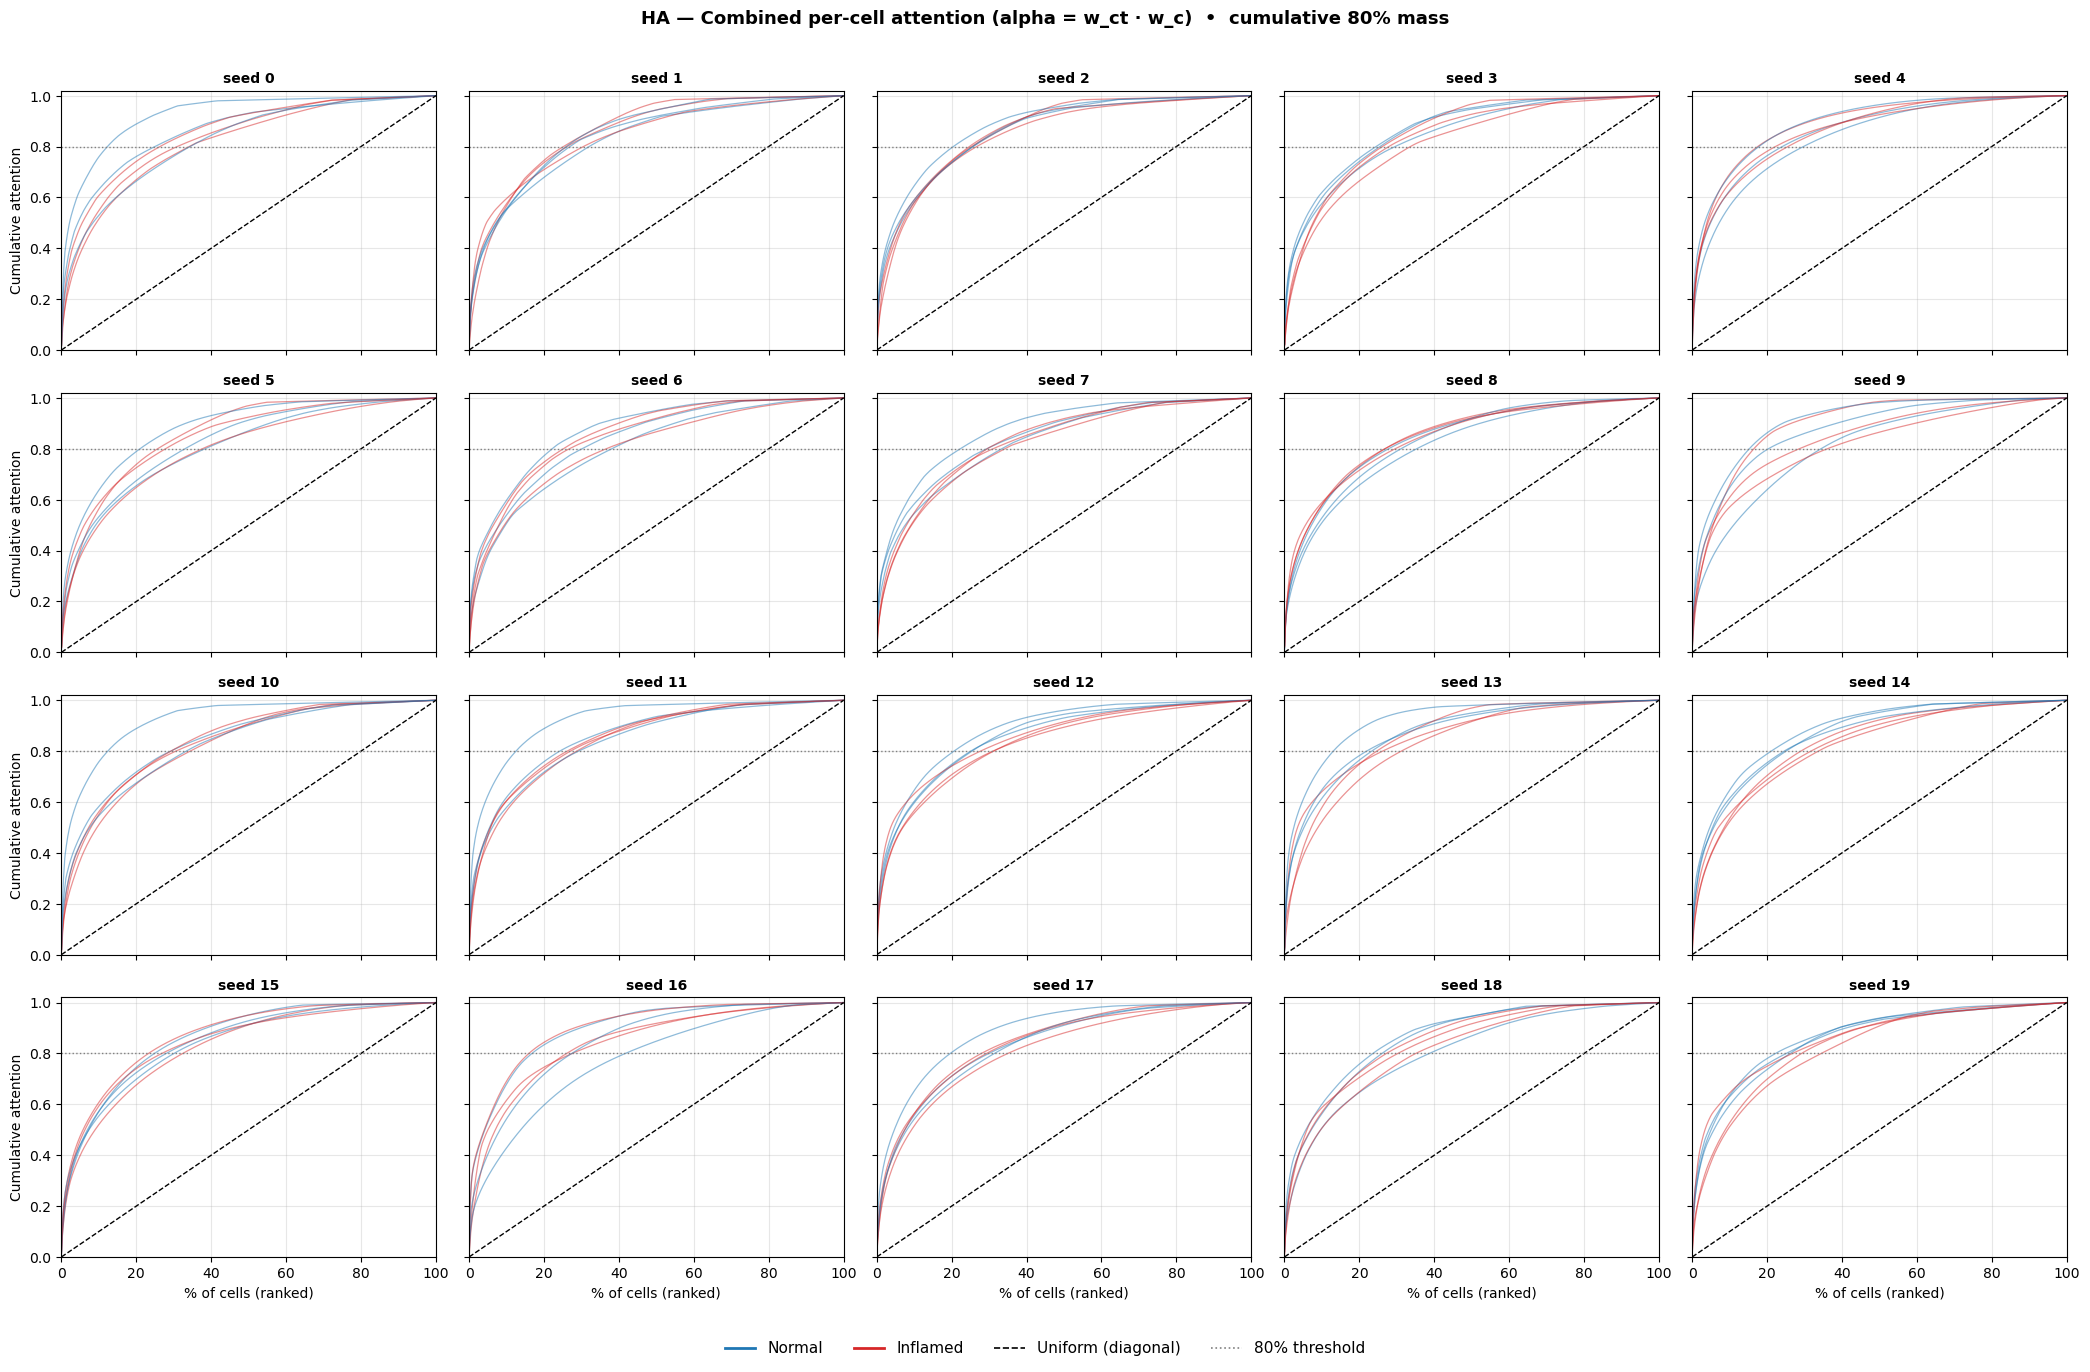

Saved -> results/ha_attention_80pct_mass_per_seed.png


In [9]:
SEEDS_PRESENT = sorted(df_cum["seed"].unique())
n_seeds = len(SEEDS_PRESENT)
ncols = 5
nrows = int(np.ceil(n_seeds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

records_by_seed = {}
for r in all_records:
    records_by_seed.setdefault(r["seed"], []).append(r)

for ax_i, seed in enumerate(SEEDS_PRESENT):
    ax = axes[ax_i]
    for r in records_by_seed[seed]:
        a  = np.sort(r["alpha"])[::-1]
        cs = np.cumsum(a)
        x  = np.arange(1, len(a) + 1) / len(a) * 100
        ax.plot(x, cs, color=DISEASE_PALETTE[r["disease"]], alpha=0.5, linewidth=0.9)
    ax.plot([0, 100], [0, 1], color="black", linestyle="--", linewidth=1.0)
    ax.axhline(y=THRESHOLD, color="gray", linestyle=":", linewidth=1.0)
    ax.set_title(f"seed {seed}", fontsize=10, fontweight="bold")
    ax.set_xlim(0, 100); ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)
    if ax_i % ncols == 0:
        ax.set_ylabel("Cumulative attention")
    if ax_i // ncols == nrows - 1:
        ax.set_xlabel("% of cells (ranked)")

for ax in axes[len(SEEDS_PRESENT):]:
    ax.axis("off")

legend = [
    Line2D([0], [0], color=DISEASE_PALETTE["Normal"],         label="Normal", linewidth=2),
    Line2D([0], [0], color=DISEASE_PALETTE["Inflamed"], label="Inflamed", linewidth=2),
    Line2D([0], [0], color="black", linestyle="--", label="Uniform (diagonal)", linewidth=1.2),
    Line2D([0], [0], color="gray",  linestyle=":",  label=f"{int(THRESHOLD*100)}% threshold", linewidth=1.2),
]
fig.legend(handles=legend, loc="lower center", ncol=4, frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("HA — Combined per-cell attention (alpha = w_ct · w_c)  •  cumulative 80% mass", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
out = os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass_per_seed.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

## Combined plot — all donor-evaluations on one axis

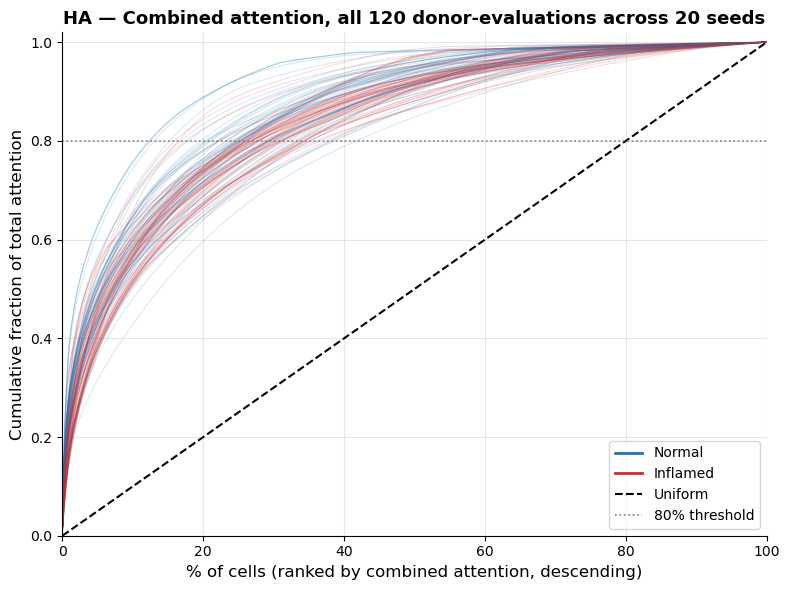

Saved -> results/ha_attention_80pct_mass_combined.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for r in all_records:
    a  = np.sort(r["alpha"])[::-1]
    cs = np.cumsum(a)
    x  = np.arange(1, len(a) + 1) / len(a) * 100
    ax.plot(x, cs, color=DISEASE_PALETTE[r["disease"]], alpha=0.18, linewidth=0.7)

ax.plot([0, 100], [0, 1], color="black", linestyle="--", linewidth=1.5, label="Uniform")
ax.axhline(y=THRESHOLD, color="gray", linestyle=":", linewidth=1.2, label=f"{int(THRESHOLD*100)}% threshold")
legend = [
    Line2D([0], [0], color=DISEASE_PALETTE["Normal"],        label="Normal", linewidth=2),
    Line2D([0], [0], color=DISEASE_PALETTE["Inflamed"], label="Inflamed", linewidth=2),
    Line2D([0], [0], color="black", linestyle="--", label="Uniform", linewidth=1.5),
    Line2D([0], [0], color="gray",  linestyle=":",  label=f"{int(THRESHOLD*100)}% threshold", linewidth=1.2),
]
ax.legend(handles=legend, fontsize=10, loc="lower right")
ax.set_xlabel("% of cells (ranked by combined attention, descending)", fontsize=12)
ax.set_ylabel("Cumulative fraction of total attention", fontsize=12)
ax.set_title(f"HA — Combined attention, all {len(all_records)} donor-evaluations across 20 seeds",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 100); ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass_combined.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

## Bonus 1 — Level-2 (cell-type) attention concentration

How many cell-types are needed to cover 80% of `w_ct` mass per donor? Distribution length is `N_CT` (per-patient) so we get an integer in `[1, N_CT]`.

Cell-type attention concentration:
  Mean cell-types for 80% : 41.2 / 68
  Median                  : 41
  Range                   : 22 – 52


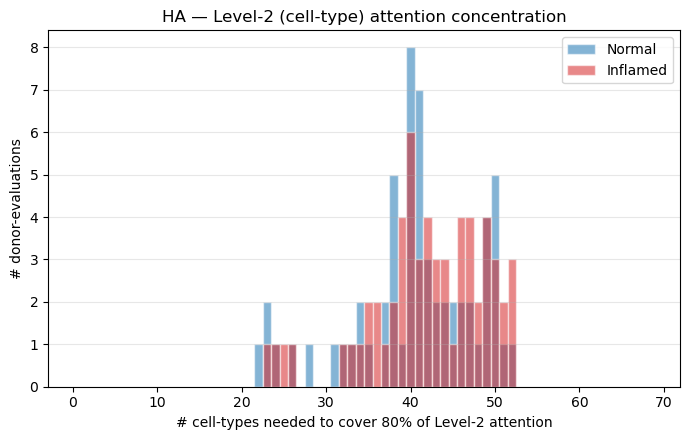

Saved -> results/ha_attention_80pct_mass_celltype.png


In [11]:
ct_rows = []
for r in all_records:
    w = np.sort(r["w_ct"])[::-1]
    cs = np.cumsum(w)
    k = int(np.searchsorted(cs, THRESHOLD) + 1)
    ct_rows.append({
        "seed":     r["seed"],
        "donor_id": r["donor_id"],
        "disease":  r["disease"],
        "n_ct":     N_CT,
        "n_ct_80pct": k,
        "pct_ct_80pct": 100.0 * k / N_CT,
    })
df_ct = pd.DataFrame(ct_rows)
df_ct.to_csv(os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass_celltype.csv"), index=False)

print("Cell-type attention concentration:")
print(f"  Mean cell-types for 80% : {df_ct['n_ct_80pct'].mean():.1f} / {N_CT}")
print(f"  Median                  : {df_ct['n_ct_80pct'].median():.0f}")
print(f"  Range                   : {df_ct['n_ct_80pct'].min()} – {df_ct['n_ct_80pct'].max()}")

# Histogram split by disease
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.arange(0.5, N_CT + 1.5, 1)
for label, color in DISEASE_PALETTE.items():
    vals = df_ct.loc[df_ct["disease"] == label, "n_ct_80pct"]
    ax.hist(vals, bins=bins, alpha=0.55, color=color, label=label, edgecolor="white")
ax.set_xlabel("# cell-types needed to cover 80% of Level-2 attention")
ax.set_ylabel("# donor-evaluations")
ax.set_title("HA — Level-2 (cell-type) attention concentration")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass_celltype.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

## Bonus 2 — Level-1 (within-celltype) attention concentration

For each `(donor, cell-type)` group, how many cells within the group cover 80% of the within-group softmax (`w_c`)? Aggregated across all such groups.

Within-celltype Level-1 attention concentration:
  Mean % cells per group : 80.6%
  Median                 : 78.8%
  Mean group size        : 74 cells


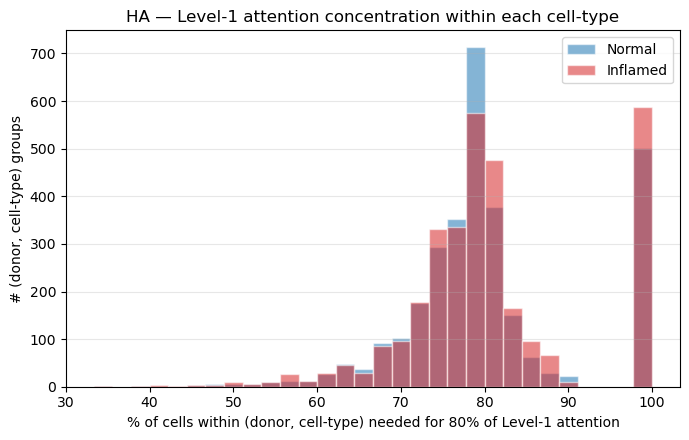

Saved -> results/ha_attention_80pct_mass_within_celltype.png


In [12]:
within_rows = []
for r in all_records:
    cells_w_c   = r["w_c"]
    cells_ctidx = r["cell_ct"]
    for ct in np.unique(cells_ctidx):
        mask = cells_ctidx == ct
        w = np.sort(cells_w_c[mask])[::-1]
        n = len(w)
        if n == 0: continue
        cs = np.cumsum(w)
        k = int(np.searchsorted(cs, THRESHOLD) + 1)
        within_rows.append({
            "seed":      r["seed"],
            "donor_id":  r["donor_id"],
            "disease":   r["disease"],
            "ct_idx":    int(ct),
            "n_cells":   n,
            "n_cells_80pct": k,
            "pct_cells_80pct": 100.0 * k / n,
        })
df_within = pd.DataFrame(within_rows)
df_within.to_csv(os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass_within_celltype.csv"), index=False)

print("Within-celltype Level-1 attention concentration:")
print(f"  Mean % cells per group : {df_within['pct_cells_80pct'].mean():.1f}%")
print(f"  Median                 : {df_within['pct_cells_80pct'].median():.1f}%")
print(f"  Mean group size        : {df_within['n_cells'].mean():.0f} cells")

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, color in DISEASE_PALETTE.items():
    vals = df_within.loc[df_within["disease"] == label, "pct_cells_80pct"]
    ax.hist(vals, bins=30, alpha=0.55, color=color, label=label, edgecolor="white")
ax.set_xlabel("% of cells within (donor, cell-type) needed for 80% of Level-1 attention")
ax.set_ylabel("# (donor, cell-type) groups")
ax.set_title("HA — Level-1 attention concentration within each cell-type")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "ha_attention_80pct_mass_within_celltype.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

## Files written

```
results/ha_attention_80pct_mass.csv                       (per donor combined-alpha summary)
results/ha_attention_80pct_mass_per_seed.png              (20-panel cumulative curves)
results/ha_attention_80pct_mass_combined.png              (single-panel cumulative)
results/ha_attention_80pct_mass_celltype.csv              (Level-2 summary)
results/ha_attention_80pct_mass_celltype.png              (Level-2 histogram)
results/ha_attention_80pct_mass_within_celltype.csv       (Level-1 within-CT summary)
results/ha_attention_80pct_mass_within_celltype.png       (Level-1 histogram)
```

These are directly comparable to the SAP plots in
`5_fold_cv_5k/celltype_inference/cell_type_importance_attention_latest.ipynb`:
the **combined-alpha** view is the closest analogue (both distributions sum to
1 over a donor's cells), and the Level-1 / Level-2 panels expose where HA's
extra interpretability comes from compared to flat SAP.


## Per-donor mean attention concentration (bar plot)\n\nMean `n_ct_80pct` across seeds for each donor, colored by disease label.

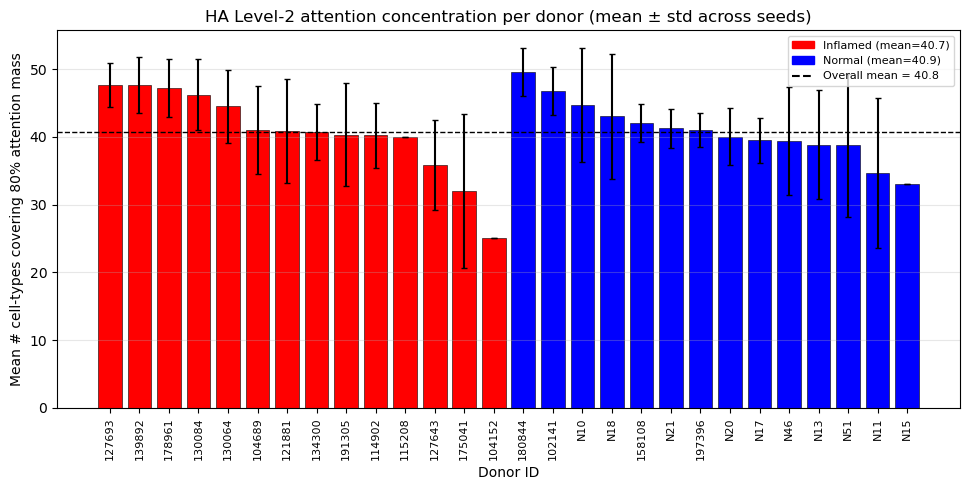

Saved results/ha_attention_80pct_mass_per_donor_bar.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

ct_df = pd.read_csv("results/ha_attention_80pct_mass_celltype.csv")

donor_stats = (
    ct_df.groupby(["donor_id", "disease"], as_index=False)
         .agg(mean_n_ct_80pct=("n_ct_80pct", "mean"),
              std_n_ct_80pct =("n_ct_80pct", "std"),
              n_seeds        =("n_ct_80pct", "size"))
)

donor_stats = donor_stats.sort_values(["disease", "mean_n_ct_80pct"],
                                      ascending=[True, False]).reset_index(drop=True)

colors = donor_stats["disease"].map(
    lambda d: "red" if "Inflamed" in str(d) else "blue"
).tolist()

summary = donor_stats.groupby("disease")["mean_n_ct_80pct"].mean()
overall_mean = donor_stats["mean_n_ct_80pct"].mean()

fig, ax = plt.subplots(figsize=(max(8, 0.35 * len(donor_stats)), 5))
x = np.arange(len(donor_stats))
ax.bar(x, donor_stats["mean_n_ct_80pct"],
       yerr=donor_stats["std_n_ct_80pct"].fillna(0),
       color=colors, edgecolor="black", linewidth=0.4, capsize=2)

ax.axhline(overall_mean, color="black", linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(donor_stats["donor_id"].astype(str), rotation=90, fontsize=8)
ax.set_xlabel("Donor ID")
ax.set_ylabel("Mean # cell-types covering 80% attention mass")
ax.set_title("HA Level-2 attention concentration per donor (mean \u00b1 std across seeds)")

legend_handles = [
    Patch(color="red",  label=f"Inflamed (mean={summary.loc['Inflamed']:.1f})"),
    Patch(color="blue", label=f"Normal (mean={summary.loc['Normal']:.1f})"),
    Line2D([0],[0], color="black", linestyle="--",
           label=f"Overall mean = {overall_mean:.1f}"),
]
ax.legend(handles=legend_handles, loc="best", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = "results/ha_attention_80pct_mass_per_donor_bar.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved", out)


## Per-donor attention-concentration summary stats

Mean / median / min / max of donor-level mean `n_ct_80pct`, split by disease and overall.

In [14]:
import pandas as pd

ct_df = pd.read_csv("results/ha_attention_80pct_mass_celltype.csv")

donor_means = (ct_df.groupby(["donor_id", "disease"])["n_ct_80pct"]
                    .mean()
                    .reset_index())

by_disease = (donor_means.groupby("disease")["n_ct_80pct"]
                         .agg(["mean", "median", "std", "min", "max", "count"])
                         .round(2))

overall = (donor_means["n_ct_80pct"]
              .agg(["mean", "median", "std", "min", "max", "count"])
              .to_frame().T
              .round(2))
overall.index = ["Overall"]

summary = pd.concat([by_disease, overall])
summary.to_csv("results/ha_attention_80pct_mass_per_donor_stats.csv")
print(summary)


           mean  median   std   min    max  count
Inflamed  40.66   40.76  6.39  25.0  47.67   14.0
Normal    40.88   40.50  4.32  33.0  49.50   14.0
Overall   40.77   40.76  5.36  25.0  49.50   28.0


## Top-20 cell-types by mean Level-2 attention

Average each cell-type's Level-2 attention weight (`w_ct`) across all donor-evaluations,
overall and per disease. Reports the top 20 and saves a bar plot.

Top-20 cell-types by mean Level-2 attention (overall):
                          mean_attn  std_attn    n
cell_type                                         
Enterocytes TMIGD1 MEP1A     0.0311    0.0185  120
Goblet cells MUC2 TFF1       0.0301    0.0173  120
Goblet cells MUC2 TFF1-      0.0291    0.0149  120
Epithelial Cycling cells     0.0291    0.0117  120
Stem cells OLFM4 PCNA        0.0290    0.0116  120
Enterocytes BEST4            0.0284    0.0148  120
Stem cells OLFM4 LGR5        0.0276    0.0102  120
Stem cells OLFM4             0.0266    0.0094  120
Goblet cells SPINK4          0.0218    0.0142  120
Enterocytes CA1 CA2 CA4-     0.0189    0.0149  120
Tuft cells                   0.0181    0.0073  120
Enteroendocrine cells        0.0174    0.0145  120
Endothelial cells DARC       0.0166    0.0030  120
DC2 CD1D                     0.0164    0.0034  120
DC1                          0.0158    0.0031  120
Fibroblasts SMOC2 PTGIS      0.0157    0.0035  120
DC2 CD1D-                  

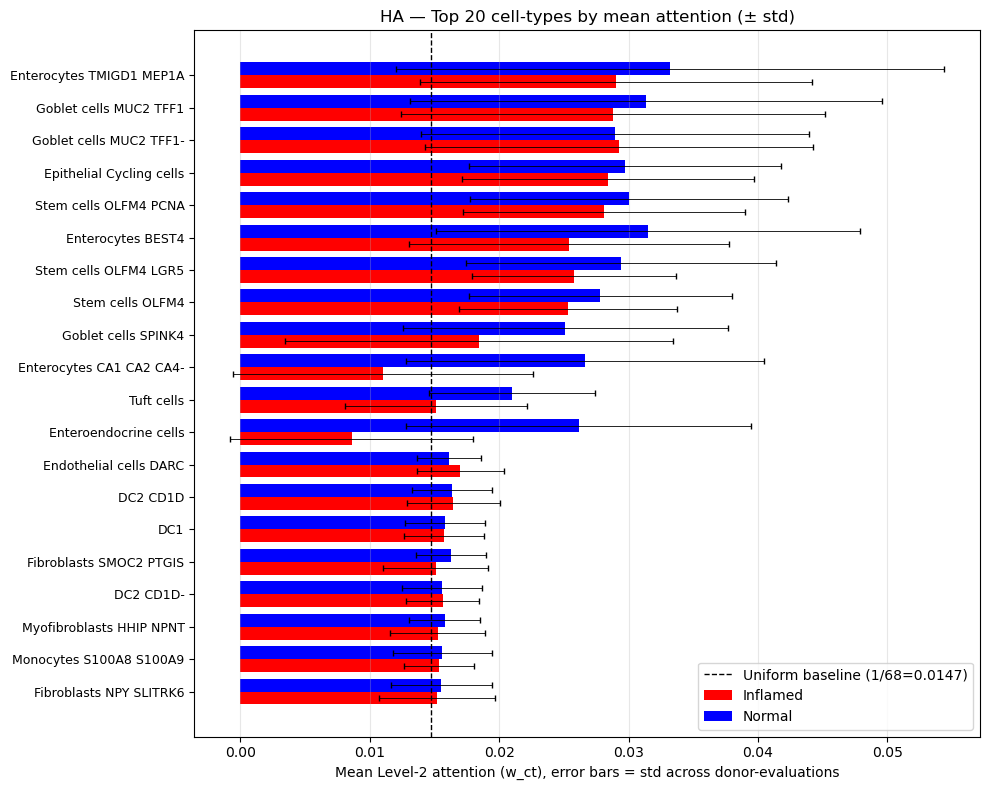


Saved -> results/ha_top20_celltypes_attention.png


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 20
INV_CT = {idx: name for name, idx in CT_DICT.items()}

rows = []
for r in all_records:
    w = r["w_ct"]
    for idx, val in enumerate(w):
        rows.append({
            "seed":      r["seed"],
            "donor_id":  r["donor_id"],
            "disease":   r["disease"],
            "ct_idx":    idx,
            "cell_type": INV_CT[idx],
            "w_ct":      float(val),
        })
df_wct = pd.DataFrame(rows)

overall = (df_wct.groupby("cell_type")["w_ct"]
                 .agg(mean_attn="mean", std_attn="std", n="size")
                 .sort_values("mean_attn", ascending=False))

by_disease_mean = (df_wct.groupby(["disease", "cell_type"])["w_ct"]
                         .mean().unstack("disease"))
by_disease_std  = (df_wct.groupby(["disease", "cell_type"])["w_ct"]
                         .std().unstack("disease"))

top_overall = overall.head(TOP_N)
top_overall.round(4).to_csv(f"results/ha_top{TOP_N}_celltypes_attention.csv", float_format="%.4f")
print(f"Top-{TOP_N} cell-types by mean Level-2 attention (overall):")
print(top_overall.round(4))

fig, ax = plt.subplots(figsize=(10, max(6, 0.4 * TOP_N)))
cts = top_overall.index.tolist()[::-1]
y = np.arange(len(cts))
inflamed_mean  = by_disease_mean.loc[cts, "Inflamed"].values
normal_mean = by_disease_mean.loc[cts, "Normal"].values
inflamed_std   = by_disease_std.loc[cts,  "Inflamed"].fillna(0).values
normal_std  = by_disease_std.loc[cts,  "Normal"].fillna(0).values

h = 0.4
ax.barh(y - h/2, inflamed_mean,  height=h, color="red",  label="Inflamed",
        xerr=inflamed_std,  error_kw=dict(ecolor="black", elinewidth=0.6, capsize=2))
ax.barh(y + h/2, normal_mean, height=h, color="blue", label="Normal",
        xerr=normal_std, error_kw=dict(ecolor="black", elinewidth=0.6, capsize=2))

ax.axvline(1.0 / N_CT, color="black", linestyle="--", linewidth=1,
           label=f"Uniform baseline (1/{N_CT}={1.0/N_CT:.4f})")
ax.set_yticks(y)
ax.set_yticklabels(cts, fontsize=9)
ax.set_xlabel("Mean Level-2 attention (w_ct), error bars = std across donor-evaluations")
ax.set_title(f"HA — Top {TOP_N} cell-types by mean attention (\u00b1 std)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
out = f"results/ha_top{TOP_N}_celltypes_attention.png"
plt.savefig(out, dpi=200)
plt.show()
print(f"\nSaved -> {out}")


## Sanity check — does mean attention across all 68 cell-types sum to 1?


In [16]:
import numpy as np

per_donor_sums = np.array([r["w_ct"].sum() for r in all_records])
print(f"Per-donor w_ct sums: min={per_donor_sums.min():.6f}  "
      f"max={per_donor_sums.max():.6f}  mean={per_donor_sums.mean():.6f}")

mean_per_ct = np.mean([r["w_ct"] for r in all_records], axis=0)
print(f"# cell-types         : {len(mean_per_ct)}")
print(f"Sum of mean attention: {mean_per_ct.sum():.6f}")
print(f"(expected \u2248 1.0, since w_ct is a softmax per donor)")

# Disease-conditional check
for d in ["Inflamed", "Normal"]:
    arr = np.array([r["w_ct"] for r in all_records if r["disease"] == d])
    print(f"  {d:14s}: n={len(arr)}, mean-vector sum = {arr.mean(0).sum():.6f}")


Per-donor w_ct sums: min=1.000000  max=1.000000  mean=1.000000
# cell-types         : 68
Sum of mean attention: 1.000000
(expected ≈ 1.0, since w_ct is a softmax per donor)
  Inflamed      : n=60, mean-vector sum = 1.000000
  Normal        : n=60, mean-vector sum = 1.000000


## Mean Level-2 attention for all cell-types (with totals)

Ranked table of mean `w_ct` across all donor-evaluations for every cell-type,
split by disease, with a `TOTAL` row at the end to confirm the weights sum to 1.

In [17]:
import numpy as np
import pandas as pd

INV_CT = {idx: name for name, idx in CT_DICT.items()}

rows = []
for r in all_records:
    for idx, val in enumerate(r["w_ct"]):
        rows.append({
            "disease":   r["disease"],
            "cell_type": INV_CT[idx],
            "w_ct":      float(val),
        })
df_wct = pd.DataFrame(rows)

overall = df_wct.groupby("cell_type")["w_ct"].agg(
    mean_attn="mean", std_attn="std", n="size")

by_disease = df_wct.groupby(["disease", "cell_type"])["w_ct"].mean().unstack("disease")

full = overall.join(by_disease).sort_values("mean_attn", ascending=False)
full.columns = ["mean_attn", "std_attn", "n",
                "mean_attn_Inflamed", "mean_attn_Normal"]

# Append TOTAL row
total = pd.DataFrame({
    "mean_attn":         [full["mean_attn"].sum()],
    "std_attn":          [np.nan],
    "n":                 [full["n"].iloc[0]],
    "mean_attn_Inflamed":   [full["mean_attn_Inflamed"].sum()],
    "mean_attn_Normal":  [full["mean_attn_Normal"].sum()],
}, index=["TOTAL"])
full_with_total = pd.concat([full, total])

out_csv = "results/ha_all_celltypes_attention.csv"
full_with_total.round(4).to_csv(out_csv, float_format="%.4f")

print(f"# cell-types: {len(full)}")
print(full_with_total.round(4).to_string())
print(f"\nSaved -> {out_csv}")


# cell-types: 68
                                       mean_attn  std_attn    n  mean_attn_Inflamed  mean_attn_Normal
Enterocytes TMIGD1 MEP1A                  0.0311    0.0185  120              0.0290            0.0332
Goblet cells MUC2 TFF1                    0.0301    0.0173  120              0.0288            0.0314
Goblet cells MUC2 TFF1-                   0.0291    0.0149  120              0.0292            0.0290
Epithelial Cycling cells                  0.0291    0.0117  120              0.0284            0.0297
Stem cells OLFM4 PCNA                     0.0290    0.0116  120              0.0281            0.0300
Enterocytes BEST4                         0.0284    0.0148  120              0.0254            0.0315
Stem cells OLFM4 LGR5                     0.0276    0.0102  120              0.0258            0.0294
Stem cells OLFM4                          0.0266    0.0094  120              0.0253            0.0278
Goblet cells SPINK4                       0.0218    0.0142  120  

## Inflamed vs Normal — per-celltype attention comparison

**Method:** for each cell-type, aggregate `w_ct` per donor (mean across seeds) so each donor
contributes one independent value, then run **Mann\u2013Whitney U** (two-sided) between Inflamed
and Normal donors. Apply **Benjamini\u2013Hochberg FDR** across the 68 cell-types.
Boxplot shows the per-donor mean distribution per cell-type (outliers hidden via `showfliers=False`).

Cell-types tested: 68
Significant at FDR<0.05: 2

Top 15 by FDR:
                     cell_type  mean_inflamed  mean_normal    diff  p_value  q_value_BH
   Macrophages Metallothionein         0.0061       0.0145 -0.0084   0.0006      0.0421
         Enteroendocrine cells         0.0087       0.0243 -0.0156   0.0014      0.0478
      Enterocytes CA1 CA2 CA4-         0.0105       0.0255 -0.0150   0.0041      0.0925
        Stem cells OLFM4 GSTA1         0.0231       0.0078  0.0153   0.0072      0.1222
          Immune Cycling cells         0.0076       0.0146 -0.0069   0.0123      0.1669
 Epithelial cells METTL12 MAFB         0.0173       0.0073  0.0101   0.0180      0.1797
Enterocytes TMIGD1 MEP1A GSTA1         0.0189       0.0076  0.0113   0.0291      0.1797
                 Cycling cells         0.0121       0.0064  0.0057   0.0291      0.1797
      Macrophages CXCL9 CXCL10         0.0109       0.0050  0.0059   0.0258      0.1797
      NK-like cells ID3 ENTPD1         0.0070       0.0

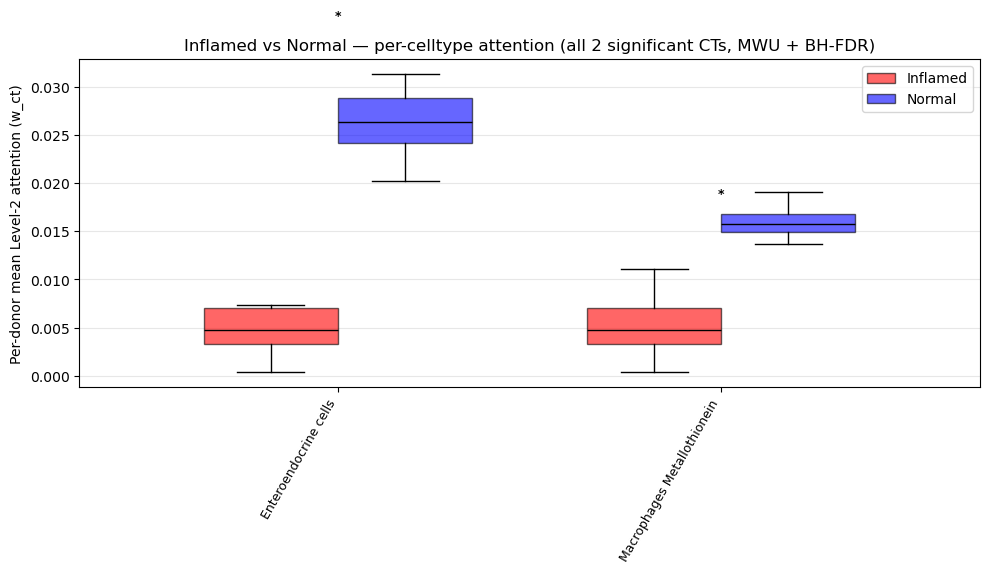


Saved -> results/ha_celltype_inflamed_vs_normal_boxplot.png
Saved stats -> results/ha_celltype_inflamed_vs_normal_stats.csv


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

INV_CT = {idx: name for name, idx in CT_DICT.items()}

rows = []
for r in all_records:
    for idx, val in enumerate(r["w_ct"]):
        rows.append({
            "seed":      r["seed"],
            "donor_id":  r["donor_id"],
            "disease":   r["disease"],
            "cell_type": INV_CT[idx],
            "w_ct":      float(val),
        })
df_wct = pd.DataFrame(rows)

# One value per donor per cell-type (mean over seeds) -> independent observations
per_donor = (df_wct.groupby(["donor_id", "disease", "cell_type"], as_index=False)["w_ct"]
                   .mean())

# Statistical test per cell-type
stats_rows = []
for ct, sub in per_donor.groupby("cell_type"):
    inflamed = sub.loc[sub["disease"] == "Inflamed", "w_ct"].values
    normal = sub.loc[sub["disease"] == "Normal",        "w_ct"].values
    if len(inflamed) < 2 or len(normal) < 2:
        continue
    stat, p = mannwhitneyu(inflamed, normal, alternative="two-sided")
    stats_rows.append({
        "cell_type":    ct,
        "n_inflamed":      len(inflamed),
        "n_normal":     len(normal),
        "mean_inflamed":   inflamed.mean(),
        "mean_normal":  normal.mean(),
        "median_inflamed": np.median(inflamed),
        "median_normal":np.median(normal),
        "diff":         inflamed.mean() - normal.mean(),
        "U":            stat,
        "p_value":      p,
    })
stats_df = pd.DataFrame(stats_rows)
stats_df["q_value_BH"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
stats_df["significant_q05"] = stats_df["q_value_BH"] < 0.05
stats_df = stats_df.sort_values("q_value_BH")

stats_df.round(4).to_csv("results/ha_celltype_inflamed_vs_normal_stats.csv",
                        index=False, float_format="%.4f")

n_sig = int(stats_df["significant_q05"].sum())
print(f"Cell-types tested: {len(stats_df)}")
print(f"Significant at FDR<0.05: {n_sig}")
print("\nTop 15 by FDR:")
print(stats_df[["cell_type","mean_inflamed","mean_normal","diff","p_value","q_value_BH"]]
      .head(15).round(4).to_string(index=False))

# Boxplot: plot ALL significant cell-types (fallback: top 20 by FDR if none significant)
sig_df = stats_df[stats_df["significant_q05"]].copy()
if len(sig_df) == 0:
    sig_df = stats_df.head(20).copy()
cts_to_plot = sig_df["cell_type"].tolist()

# Long form for boxplot; order by overall mean attention (descending)
plot_long = per_donor[per_donor["cell_type"].isin(cts_to_plot)].copy()
order = (plot_long.groupby("cell_type")["w_ct"].mean()
                  .reindex(cts_to_plot).sort_values(ascending=False).index.tolist())

# Persist for downstream proportion plots so they use the SAME cell-types in the SAME order
SIG_CTS_ORDER = order

fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(order)), 6))
positions = np.arange(len(order))
width = 0.35

box_inflamed = ax.boxplot(
    [plot_long[(plot_long.cell_type==c) & (plot_long.disease=="Inflamed")]["w_ct"].values
     for c in order],
    positions=positions - width/2, widths=width, patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"),
)
box_normal = ax.boxplot(
    [plot_long[(plot_long.cell_type==c) & (plot_long.disease=="Normal")]["w_ct"].values
     for c in order],
    positions=positions + width/2, widths=width, patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"),
)

# Annotate significance
ymax_per_ct = plot_long.groupby("cell_type")["w_ct"].quantile(0.95).reindex(order).values
for i, ct in enumerate(order):
    q = stats_df.loc[stats_df["cell_type"] == ct, "q_value_BH"].iloc[0]
    if   q < 0.001: mark = "***"
    elif q < 0.01:  mark = "**"
    elif q < 0.05:  mark = "*"
    else:           mark = "ns"
    ax.text(i, ymax_per_ct[i] * 1.05, mark, ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Per-donor mean Level-2 attention (w_ct)")
ax.set_title(f"Inflamed vs Normal — per-celltype attention (all {len(order)} significant CTs, MWU + BH-FDR)")
ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0]],
          ["Inflamed", "Normal"], loc="best")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = "results/ha_celltype_inflamed_vs_normal_boxplot.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved -> {out}")
print("Saved stats -> results/ha_celltype_inflamed_vs_normal_stats.csv")


## Inflamed vs Normal \u2014 cell-count proportions for significant cell-types

For each donor, compute the **fraction of cells** assigned to each cell-type from `cell_ct`,
then compare Inflamed vs Normal on the same 20 cell-types shown in the attention boxplot above.
Test = Mann\u2013Whitney U with BH-FDR. Outliers hidden in boxplot.

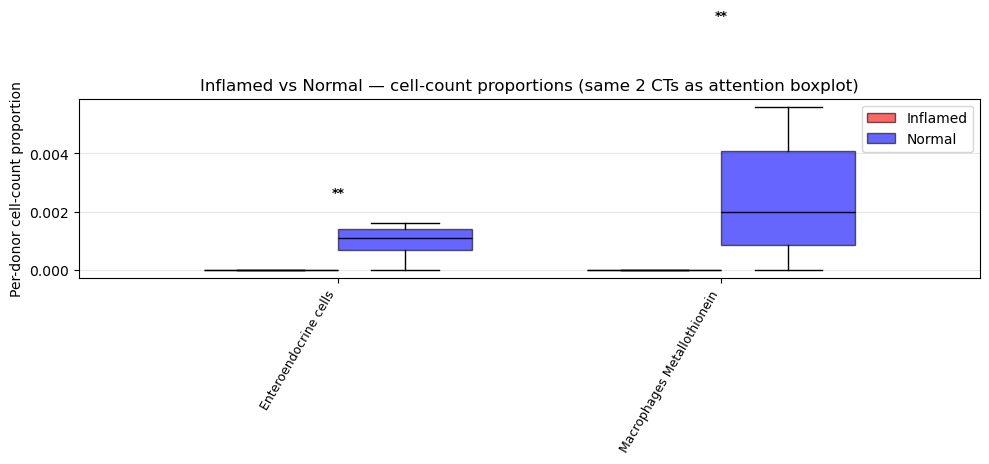

Saved -> results/ha_celltype_count_proportions_boxplot.png
Saved stats -> results/ha_celltype_count_proportions_stats.csv

Proportion stats (same 2 CTs):
                  cell_type  mean_inflamed  mean_normal    diff  p_value  q_value_BH
      Enteroendocrine cells         0.0003       0.0014 -0.0011   0.0049      0.0049
Macrophages Metallothionein         0.0008       0.0043 -0.0035   0.0040      0.0049


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

INV_CT = {idx: name for name, idx in CT_DICT.items()}

# Per-donor cell-count proportions (averaged across seeds for stability)
prop_rows = []
for r in all_records:
    counts = np.bincount(r["cell_ct"], minlength=N_CT)
    props  = counts / counts.sum()
    for idx, p in enumerate(props):
        prop_rows.append({
            "seed":      r["seed"],
            "donor_id":  r["donor_id"],
            "disease":   r["disease"],
            "cell_type": INV_CT[idx],
            "prop":      float(p),
        })
df_prop = pd.DataFrame(prop_rows)
per_donor_prop = (df_prop.groupby(["donor_id","disease","cell_type"], as_index=False)["prop"]
                         .mean())

# Use the EXACT same set + order of cell-types as the attention boxplot above
try:
    plot_cts = list(SIG_CTS_ORDER)
except NameError:
    stats_df = pd.read_csv("results/ha_celltype_inflamed_vs_normal_stats.csv")
    sig = stats_df[stats_df["significant_q05"]].copy()
    plot_cts = (per_donor_prop[per_donor_prop["cell_type"].isin(sig["cell_type"])]
                .assign(_=lambda d: d["cell_type"])
                .groupby("cell_type")["prop"].mean()
                .reindex(sig["cell_type"]).sort_values(ascending=False).index.tolist())

# Stats on cell-count proportions (same CTs as attention plot)
prop_stats = []
for ct in plot_cts:
    sub = per_donor_prop[per_donor_prop["cell_type"] == ct]
    cr = sub.loc[sub["disease"]=="Inflamed","prop"].values
    nm = sub.loc[sub["disease"]=="Normal","prop"].values
    stat, p = mannwhitneyu(cr, nm, alternative="two-sided")
    prop_stats.append({
        "cell_type":   ct,
        "mean_inflamed":  cr.mean(),
        "mean_normal": nm.mean(),
        "diff":        cr.mean() - nm.mean(),
        "p_value":     p,
    })
prop_stats_df = pd.DataFrame(prop_stats)
prop_stats_df["q_value_BH"] = multipletests(prop_stats_df["p_value"], method="fdr_bh")[1]
prop_stats_df = prop_stats_df.round(4)
prop_stats_df.to_csv("results/ha_celltype_count_proportions_stats.csv",
                     index=False, float_format="%.4f")

# Use the SAME order as the attention plot
order = plot_cts

fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(order)), 6))
positions = np.arange(len(order))
width = 0.35

box_inflamed = ax.boxplot(
    [per_donor_prop[(per_donor_prop.cell_type==c) & (per_donor_prop.disease=="Inflamed")]["prop"].values
     for c in order],
    positions=positions - width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"),
)
box_normal = ax.boxplot(
    [per_donor_prop[(per_donor_prop.cell_type==c) & (per_donor_prop.disease=="Normal")]["prop"].values
     for c in order],
    positions=positions + width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"),
)

# Significance annotation (cell-count proportion test)
ymax_per_ct = (per_donor_prop[per_donor_prop.cell_type.isin(order)]
               .groupby("cell_type")["prop"].quantile(0.95).reindex(order).values)
for i, ct in enumerate(order):
    q = prop_stats_df.loc[prop_stats_df["cell_type"] == ct, "q_value_BH"].iloc[0]
    if   q < 0.001: mark = "***"
    elif q < 0.01:  mark = "**"
    elif q < 0.05:  mark = "*"
    else:           mark = "ns"
    ax.text(i, ymax_per_ct[i] * 1.05, mark, ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Per-donor cell-count proportion")
ax.set_title(f"Inflamed vs Normal — cell-count proportions (same {len(order)} CTs as attention boxplot)")
ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0]],
          ["Inflamed", "Normal"], loc="best")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = "results/ha_celltype_count_proportions_boxplot.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")
print(f"Saved stats -> results/ha_celltype_count_proportions_stats.csv")
print(f"\nProportion stats (same {len(order)} CTs):")
print(prop_stats_df.sort_values("q_value_BH").to_string(index=False))


## Same boxplot \u2014 log-scale y-axis

Log-scale view of per-donor cell-count proportions; zeros are replaced with a small pseudocount
(half the smallest non-zero value) so they remain visible on a log axis.

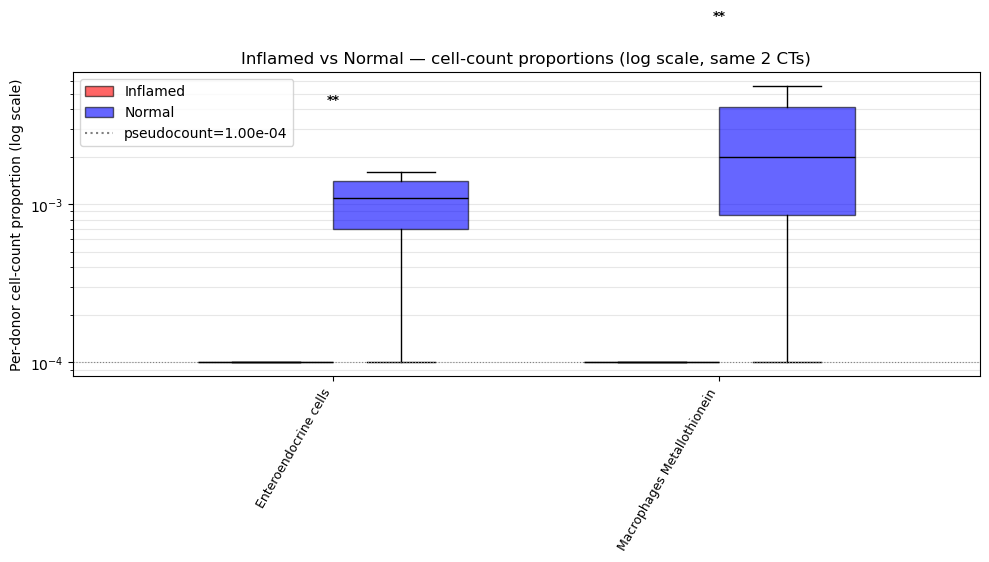

Saved -> results/ha_celltype_count_proportions_boxplot_log.png


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse per_donor_prop, plot_cts, prop_stats_df, and order from previous cell.
try:
    per_donor_prop
    plot_cts
    prop_stats_df
    order
except NameError:
    raise RuntimeError("Run the cell-count proportion cell above first.")

# Replace zeros with half the smallest non-zero proportion (pseudocount for log axis)
nonzero_min = per_donor_prop.loc[per_donor_prop["prop"] > 0, "prop"].min()
pseudo = nonzero_min / 2
plot_df = per_donor_prop.copy()
plot_df["prop_log"] = plot_df["prop"].where(plot_df["prop"] > 0, pseudo)

fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(order)), 6))
positions = np.arange(len(order))
width = 0.35

box_inflamed = ax.boxplot(
    [plot_df[(plot_df.cell_type==c) & (plot_df.disease=="Inflamed")]["prop_log"].values
     for c in order],
    positions=positions - width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"),
)
box_normal = ax.boxplot(
    [plot_df[(plot_df.cell_type==c) & (plot_df.disease=="Normal")]["prop_log"].values
     for c in order],
    positions=positions + width/2, widths=width, patch_artist=True, showfliers=False,
    boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
    medianprops=dict(color="black"),
)
ax.set_yscale("log")

ymax_per_ct = (plot_df[plot_df.cell_type.isin(order)]
               .groupby("cell_type")["prop_log"].quantile(0.95).reindex(order).values)
for i, ct in enumerate(order):
    q = prop_stats_df.loc[prop_stats_df["cell_type"] == ct, "q_value_BH"].iloc[0]
    if   q < 0.001: mark = "***"
    elif q < 0.01:  mark = "**"
    elif q < 0.05:  mark = "*"
    else:           mark = "ns"
    ax.text(i, ymax_per_ct[i] * 1.8, mark, ha="center", fontsize=9, fontweight="bold")

ax.axhline(pseudo, color="gray", linestyle=":", linewidth=0.8,
           label=f"pseudocount = {pseudo:.2e} (for zeros)")

ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Per-donor cell-count proportion (log scale)")
ax.set_title(f"Inflamed vs Normal — cell-count proportions (log scale, same {len(order)} CTs)")
ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0],
           plt.Line2D([0],[0], color="gray", linestyle=":")],
          ["Inflamed", "Normal", f"pseudocount={pseudo:.2e}"], loc="best")
ax.grid(axis="y", which="both", alpha=0.3)
plt.tight_layout()
out = "results/ha_celltype_count_proportions_boxplot_log.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")


## Per-celltype cumulative Level-1 attention curves

For each cell-type, plot cumulative within-celltype attention (`w_c`) vs. % of cells
(ranked descending), with one curve per (seed, donor) that contains that cell-type.
A horizontal line marks the 80% threshold, and an annotation reports the mean # cells
needed to reach 80% across all (seed, donor) groups for that cell-type. One PNG per
cell-type is saved in `results/per_celltype_cumulative/`.

In [21]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT_DIR = "results/per_celltype_cumulative"
os.makedirs(OUT_DIR, exist_ok=True)

INV_CT = {idx: name for name, idx in CT_DICT.items()}
THRESH = 0.80

def safe_name(s):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", s).strip("_")

# Collect per (cell-type, seed, donor) sorted within-CT attention curves
per_ct = {ct_idx: [] for ct_idx in range(N_CT)}
for r in all_records:
    cells_w_c   = r["w_c"]
    cells_ctidx = r["cell_ct"]
    for ct_idx in np.unique(cells_ctidx):
        mask = cells_ctidx == ct_idx
        w = cells_w_c[mask]
        if w.size == 0:
            continue
        w_sorted = np.sort(w)[::-1]
        cs = np.cumsum(w_sorted)
        k80 = int(np.searchsorted(cs, THRESH) + 1)
        per_ct[int(ct_idx)].append({
            "seed":      r["seed"],
            "donor_id":  r["donor_id"],
            "disease":   r["disease"],
            "n_cells":   int(w.size),
            "cum":       cs,
            "k80":       k80,
            "pct80":     100.0 * k80 / w.size,
        })

summary_rows = []
for ct_idx in range(N_CT):
    ct_name = INV_CT[ct_idx]
    curves  = per_ct[ct_idx]
    if not curves:
        print(f"  skip [{ct_idx:>2}] {ct_name}: no donor has this cell-type")
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    for c in curves:
        color = DISEASE_PALETTE.get(c["disease"], "gray")
        x = np.arange(1, len(c["cum"]) + 1) / len(c["cum"]) * 100
        ax.plot(x, c["cum"], color=color, alpha=0.35, linewidth=0.7)

    ax.plot([0, 100], [0, 1], color="black", linestyle="--", linewidth=1.0,
            label="Uniform")
    ax.axhline(THRESH, color="gray", linestyle=":", linewidth=1.0,
               label=f"{int(THRESH*100)}% threshold")

    mean_pct80 = float(np.mean([c["pct80"] for c in curves]))
    mean_k80   = float(np.mean([c["k80"]   for c in curves]))
    mean_n     = float(np.mean([c["n_cells"] for c in curves]))

    handles = [
        Line2D([0],[0], color=DISEASE_PALETTE["Normal"],        label="Normal", lw=2),
        Line2D([0],[0], color=DISEASE_PALETTE["Inflamed"], label="Inflamed", lw=2),
        Line2D([0],[0], color="black", linestyle="--", label="Uniform", lw=1),
        Line2D([0],[0], color="gray",  linestyle=":",  label=f"{int(THRESH*100)}% threshold", lw=1),
    ]
    ax.legend(handles=handles, fontsize=8, loc="lower right")

    ax.set_xlim(0, 100); ax.set_ylim(0, 1.02)
    ax.set_xlabel("% of cells within cell-type (ranked, desc.)")
    ax.set_ylabel("Cumulative within-CT attention (w_c)")
    ax.set_title(f"[{ct_idx}] {ct_name}\n"
                 f"n_groups={len(curves)}  mean cells for {int(THRESH*100)}%: "
                 f"{mean_k80:.1f}/{mean_n:.0f}  ({mean_pct80:.1f}%)",
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = os.path.join(OUT_DIR, f"ct{ct_idx:02d}_{safe_name(ct_name)}.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close(fig)

    summary_rows.append({
        "ct_idx":         ct_idx,
        "cell_type":      ct_name,
        "n_groups":       len(curves),
        "mean_n_cells":   mean_n,
        "mean_k_80pct":   mean_k80,
        "mean_pct_80pct": mean_pct80,
    })

import pandas as pd
summary = pd.DataFrame(summary_rows).sort_values("mean_pct_80pct")
summary.to_csv("results/per_celltype_cumulative_summary.csv", index=False,
               float_format="%.4f")
print(f"\nSaved {len(summary)} per-celltype PNGs in {OUT_DIR}/")
print("Top 10 most-concentrated cell-types (fewest % cells for 80%):")
print(summary.head(10).to_string(index=False))
print("\nTop 10 most-diffuse cell-types (highest % cells for 80%):")
print(summary.tail(10).to_string(index=False))



Saved 68 per-celltype PNGs in results/per_celltype_cumulative/
Top 10 most-concentrated cell-types (fewest % cells for 80%):
 ct_idx                cell_type  n_groups  mean_n_cells  mean_k_80pct  mean_pct_80pct
     13 Enterocytes CA1 CA2 CA4-        73    481.767123    345.397260       72.559432
     14 Enterocytes TMIGD1 MEP1A       120    413.225000    306.483333       73.527119
      3            Cycling cells        49     32.551020     23.734694       73.564222
     55         Stem cells OLFM4       120    122.883333     89.583333       73.589186
     35              Macrophages       120     75.233333     55.941667       74.437448
     17 Epithelial Cycling cells       120    106.708333     78.583333       74.879353
     62              T cells CD8       120     81.433333     60.633333       74.891453
     57    Stem cells OLFM4 LGR5       120     97.008333     72.508333       74.990648
     60         T cells CD4 FOSB       120    207.183333    155.683333       75.075557
    

## Direction summary table — significant CTs

For each cell-type significant in the **attention** test (FDR < 0.05), tick which of the four
categories it belongs to based on the sign of `diff = mean_inflamed - mean_normal`:
- **Higher attention in Inflamed** (attention diff > 0)
- **Higher attention in Normal** (attention diff < 0)
- **Higher proportion in Inflamed** (proportion diff > 0; significance ignored)
- **Higher proportion in Normal** (proportion diff < 0; significance ignored)

In [22]:
import pandas as pd

attn = pd.read_csv("results/ha_celltype_inflamed_vs_normal_stats.csv")
prop = pd.read_csv("results/ha_celltype_count_proportions_stats.csv")

sig = attn[attn["significant_q05"]].copy()
sig = sig.merge(prop[["cell_type", "diff", "q_value_BH"]]
                  .rename(columns={"diff": "prop_diff", "q_value_BH": "prop_q"}),
                on="cell_type", how="left")

TICK = "\u2713"
table = pd.DataFrame({
    "cell_type":                   sig["cell_type"],
    "higher_attention_in_Inflamed":   [TICK if d > 0 else "" for d in sig["diff"]],
    "higher_proportion_in_Inflamed":  [TICK if (pd.notna(d) and d > 0) else "" for d in sig["prop_diff"]],
    "higher_attention_in_Normal":  [TICK if d < 0 else "" for d in sig["diff"]],
    "higher_proportion_in_Normal": [TICK if (pd.notna(d) and d < 0) else "" for d in sig["prop_diff"]],
    "proportion_significant_q05":  [TICK if (pd.notna(q) and q < 0.05) else "" for q in sig["prop_q"]],
})

# Order: (1) both higher in Inflamed, (2) both higher in Normal, (3) attention/proportion disagree (end).
# Within each block: by |attention diff| descending.
def _grp(row):
    a, p = row["diff"], row["prop_diff"]
    if pd.isna(p):                    return 3
    if a > 0 and p > 0:               return 0  # both Inflamed
    if a < 0 and p < 0:               return 1  # both Normal
    return 2                                       # disagreement
sig_sorted = sig.assign(
    _grp=sig.apply(_grp, axis=1),
    _key=sig["diff"].abs()
).sort_values(["_grp", "_key"], ascending=[True, False])
table = table.set_index("cell_type").reindex(sig_sorted["cell_type"]).reset_index()

out_csv = "results/ha_celltype_direction_summary.csv"
table.to_csv(out_csv, index=False)
print(f"Saved -> {out_csv}")
print(f"\nDirection summary for {len(table)} significant cell-types:\n")
print(table.to_string(index=False))

Saved -> results/ha_celltype_direction_summary.csv

Direction summary for 2 significant cell-types:

                  cell_type higher_attention_in_Inflamed higher_proportion_in_Inflamed higher_attention_in_Normal higher_proportion_in_Normal proportion_significant_q05
      Enteroendocrine cells                                                                                     ✓                           ✓                          ✓
Macrophages Metallothionein                                                                                     ✓                           ✓                          ✓
